<a href="https://colab.research.google.com/github/roeiyanku/UAV_Sound_Classification_Project/blob/main/01_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preprocessing and Preparation
This notebook downloads relavent data and preprocesses it for feature extraction.

## 0) Paths & Constants

In [ ]:
# ── All paths and settings are defined here ──────────────────────────────────

# ── Choose dataset ────────────────────────────────────────────────────────────
DATASET = "Multiclass_Drone_Audio"    # "fan", "pump", "slider", "valve", "Binary_Drone_Audio", "AeroSonicDB", "Multiclass_Drone_Audio"
#DB_LEVEL = "0_dB"
#ID = "id_00"          # "id_00" "id_02", "id_04", "id_06"

#DATA_DIR = f"/content/drive/MyDrive/Data/MIMII/{DATASET}_sound_data/{DB_LEVEL}/{ID}"
DATA_DIR = f"/content/drive/MyDrive/Data/Multiclass_Drone_Audio"

#SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/processed/splits/{DATASET}/{DB_LEVEL}/{ID}"
SAVE_DIR = f"/content/drive/MyDrive/Final Project RMOT/processed/splits/Multiclass_Drone_Audio"


RANDOM_STATE = 42
TEST_SIZE    = 0.30   # fraction used for val+test combined
VAL_FRACTION = 0.50   # fraction of temp set used for validation


## 1) Setup and data path
Choose the option that matches where your data is stored.

**Expected folder structure**
```text
data/
├── normal/
│   └── ... .wav files
└── abnormal/
    └── ... .wav files
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import glob

files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

print("Data directory:", DATA_DIR)
print("Number of audio files found:", len(files))
print("Example files:", files[:5])


Data directory: /content/drive/MyDrive/Data/Multiclass_Drone_Audio
Number of audio files found: 11704
Example files: ['/content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-232816-A-231.wav', '/content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-232816-A-232.wav', '/content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-232816-A-233.wav', '/content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-232816-A-234.wav', '/content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-233019-A-310.wav']


## 2) Install and Import Libraries

First, install `librosa`, a common library for audio analysis, if it's not already present.

In [ ]:
!pip install librosa soundfile

## 3) Load and Inspect Audio Files

Now, let's load one of the audio files and inspect its properties. This helps us understand the audio characteristics, such as sample rate and duration, which are important for subsequent feature extraction steps.

Loading example audio file: /content/drive/MyDrive/Data/Multiclass_Drone_Audio/normal/5-232816-A-232.wav
Sample rate (sr): 16000 Hz
Audio duration: 0.98 seconds
Number of samples: 15604
First 10 samples: [ 0.01522827  0.01342773  0.01141357  0.00857544  0.00476074  0.00216675
 -0.00109863 -0.00360107 -0.00509644 -0.00631714]


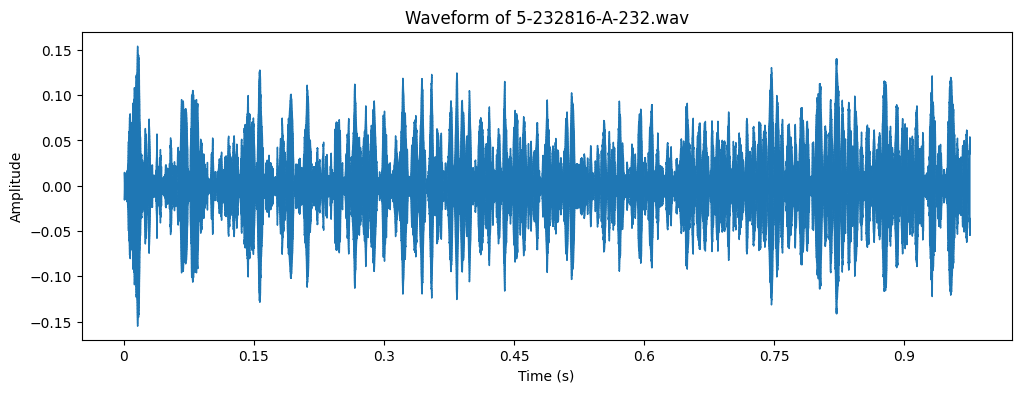

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Take the first audio file as an example
if files:
    example_audio_path = files[1]
    print(f"Loading example audio file: {example_audio_path}")

    # Load the audio file
    y, sr = librosa.load(example_audio_path, sr=None) # sr=None preserves original sample rate

    print(f"Sample rate (sr): {sr} Hz")
    print(f"Audio duration: {len(y)/sr:.2f} seconds")
    print(f"Number of samples: {len(y)}")
    print(f"First 10 samples: {y[:10]}")

    # Optionally, plot the waveform
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f'Waveform of {os.path.basename(example_audio_path)}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()
else:
    print("No audio files found in the specified directory.")

## 4) Data Splitting (Train, Validation, Test)

Now, we split the paths to our audio files into training, validation, and test sets. It's crucial to do this in a stratified manner to ensure that the proportion of 'normal' and 'abnormal' samples is maintained across all splits.

In [ ]:
from sklearn.model_selection import train_test_split
import os

labels = [os.path.basename(os.path.dirname(f)) for f in files]

unique_labels = sorted(list(set(labels)))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
int_labels = [label_to_int[label] for label in labels]

print(f"Unique labels found: {unique_labels}")

# Split data into training and a temporary set (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    files, int_labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=int_labels
)

# Split the temporary set into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_FRACTION, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\nTotal audio files: {len(files)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(files):.2%})")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(files):.2%})")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(files):.2%})")

from collections import Counter

train_label_counts = Counter([unique_labels[i] for i in y_train])
val_label_counts = Counter([unique_labels[i] for i in y_val])
test_label_counts = Counter([unique_labels[i] for i in y_test])

print(f"\nTraining set label distribution: {train_label_counts}")
print(f"Validation set label distribution: {val_label_counts}")
print(f"Test set label distribution: {test_label_counts}")


Unique labels found: ['drone', 'normal']

Total audio files: 11704
Training set size: 8192 (69.99%)
Validation set size: 1756 (15.00%)
Test set size: 1756 (15.00%)

Training set label distribution: Counter({'normal': 7726, 'drone': 466})
Validation set label distribution: Counter({'normal': 1656, 'drone': 100})
Test set label distribution: Counter({'normal': 1656, 'drone': 100})


## 6) Save Preprocessed Data

To easily reuse these data splits in other notebooks or subsequent steps, we'll save them to a file using `joblib`.

In [ ]:
import joblib
import os

data_splits = {
    'X_train': X_train,
    'y_train': y_train,
    'X_val': X_val,
    'y_val': y_val,
    'X_test': X_test,
    'y_test': y_test,
    'unique_labels': unique_labels,
    'label_to_int': label_to_int
}

# Define the path to save the file
save_path = os.path.join(SAVE_DIR, 'processed_audio_splits.joblib')

# Save the data splits to the file
joblib.dump(data_splits, save_path)

print(f"Data splits saved successfully to: {save_path}")

Data splits saved successfully to: /content/drive/MyDrive/Final Project RMOT/processed/splits/Multiclass_Drone_Audio/processed_audio_splits.joblib
